# 1. Project Setup

In [1]:
!pip install wbgapi

In [2]:
import requests
import pandas as pd
import sqlite3
from google.colab import drive
import wbgapi as wb
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Data Extraction (API)

In [3]:
#Search the World Bank API for relevant indicator codes (ex: density)
search_results = wb.series.info(q='density')
print(search_results)

id              value
--------------  --------------------------------------------------------------------
EN.POP.DNST     Population density (people per sq. km of land area)
IC.BUS.NDNS.ZS  New business density (new registrations per 1,000 people ages 15-64)
                2 elements


In [4]:
#Define target countries
#Selected: South Korea (KOR), USA (USA), India (IND), Indonesia (IDN)
countries = ['KOR', 'USA', 'IND', 'IDN']

#Define & give names to indicator codes
indicators = {
    'NY.GDP.PCAP.PP.CD': 'gdp_per_capita',
    'SP.POP.1564.TO.ZS': 'pop_work_age_pct',
    'SP.URB.TOTL.IN.ZS':'urban_pop_pct',
    'EN.POP.DNST.IC.BUS.NDNS.ZS':'pop_density',
    'FR.INR.RINR': 'real_interest_rate',
    'FP.CPI.TOTL.ZG': 'inflation'
}

In [5]:
#Request data from the World Bank API
#Note: mrv=10 to get most recent values for the last 10 years
df = wb.data.DataFrame(indicators, countries, mrv=10)

#Preview raw structure
print(df.head())

                                 YR2015        YR2016        YR2017  \
economy series                                                        
IDN     FP.CPI.TOTL.ZG         6.363121      3.525805      3.808799   
        FR.INR.RINR            8.349911      9.224432      6.501564   
        NY.GDP.PCAP.PP.CD  10027.537300  10262.595165  10687.640922   
        SP.POP.1564.TO.ZS     66.952490     67.077798     67.198287   
        SP.URB.TOTL.IN.ZS     53.172077     53.812557     54.454102   

                                 YR2018        YR2019        YR2020  \
economy series                                                        
IDN     FP.CPI.TOTL.ZG         3.198348      3.030585      1.919835   
        FR.INR.RINR            6.471250      8.629405      9.985927   
        NY.GDP.PCAP.PP.CD  11372.097199  11986.470151  11729.367446   
        SP.POP.1564.TO.ZS     67.314100     67.422367     67.557671   
        SP.URB.TOTL.IN.ZS     55.095684     55.738205     56.278529   

    

# 3. Data Transformation

In [6]:
#Rename columns
#convert index to column and rename columns
df = df.reset_index()
df = df.rename(columns = {'economy': 'country_code',
                          'series': 'indicator'})

#replace indicator codes (ex: NY.GDP.PCAP.PP.CD) with readable names
df['indicator'] = df['indicator'].map(indicators)

In [7]:
#Reshape format
#pivot years from columns into rows so each row = single observation
df_time2row = pd.melt(df, id_vars=['country_code', 'indicator'], var_name='year', value_name='value')

#clean 'year' column
df_time2row['year'] = df_time2row['year'].str.replace('YR', '').astype(int)

In [8]:
#Data quality check
df_time2row.head(10)

,country_code,indicator,year,value
0,IDN,inflation,2015,6.363121
1,IDN,real_interest_rate,2015,8.349911
2,IDN,gdp_per_capita,2015,10027.537300
3,IDN,pop_work_age_pct,2015,66.952490
4,IDN,urban_pop_pct,2015,53.172077
5,IND,inflation,2015,4.906973
6,IND,real_interest_rate,2015,7.556488
7,IND,gdp_per_capita,2015,5425.035991
8,IND,pop_work_age_pct,2015,65.617786
9,IND,urban_pop_pct,2015,32.547299


In [9]:
#Data quality check
df_time2row.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_code  200 non-null    object 
 1   indicator     200 non-null    object 
 2   year          200 non-null    int64  
 3   value         195 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 6.4+ KB


In [10]:
#Identify missing data points
print(df_time2row[df_time2row['value'].isna()])

    country_code           indicator  year  value
156          USA  real_interest_rate  2022    NaN
166          IND  real_interest_rate  2023    NaN
176          USA  real_interest_rate  2023    NaN
186          IND  real_interest_rate  2024    NaN
196          USA  real_interest_rate  2024    NaN


In [11]:
#Check specific country (USA) to verify
print(df_time2row[df_time2row['country_code']=='USA'])

    country_code           indicator  year         value
15           USA           inflation  2015      0.118627
16           USA  real_interest_rate  2015      2.475163
17           USA      gdp_per_capita  2015  56849.469792
18           USA    pop_work_age_pct  2015     66.498081
19           USA       urban_pop_pct  2015     80.570799
35           USA           inflation  2016      1.261583
36           USA  real_interest_rate  2016      2.637731
37           USA      gdp_per_capita  2016  57976.628204
38           USA    pop_work_age_pct  2016     66.318040
39           USA       urban_pop_pct  2016     80.497665
55           USA           inflation  2017      2.130110
56           USA  real_interest_rate  2017      2.371619
57           USA      gdp_per_capita  2017  60047.719073
58           USA    pop_work_age_pct  2017     66.121929
59           USA       urban_pop_pct  2017     80.401868
75           USA           inflation  2018      2.442583
76           USA  real_interest

In [12]:
#Drop 5 missing data points
#Note: Missing 'real_interest_rate likely due to reporting lags for World Bank datasets
df_clean = df_time2row.dropna(subset=['value'])
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 195 entries, 0 to 199
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_code  195 non-null    object 
 1   indicator     195 non-null    object 
 2   year          195 non-null    int64  
 3   value         195 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 7.6+ KB


# 4. Data Loading (SQLite)

In [13]:
#Create '.db' file in current directory
conn = sqlite3.connect('macroeconomic_indicator_data.db')
cursor = conn.cursor()

In [14]:
#Load data
df_clean.to_sql('macroecon_data', conn, if_exists='replace', index=True)

195

In [15]:
#Check data uploaded
conn = sqlite3.connect('macroeconomic_indicator_data.db')
result = pd.read_sql_query("SELECT * from macroecon_data", conn)
print(result)

     index country_code           indicator  year         value
0        0          IDN           inflation  2015      6.363121
1        1          IDN  real_interest_rate  2015      8.349911
2        2          IDN      gdp_per_capita  2015  10027.537300
3        3          IDN    pop_work_age_pct  2015     66.952490
4        4          IDN       urban_pop_pct  2015     53.172077
..     ...          ...                 ...   ...           ...
190    194          KOR       urban_pop_pct  2024     81.168253
191    195          USA           inflation  2024      2.949525
192    197          USA      gdp_per_capita  2024  85809.900385
193    198          USA    pop_work_age_pct  2024     64.746693
194    199          USA       urban_pop_pct  2024     80.124780

[195 rows x 5 columns]


In [16]:
conn.close()

# 5. Visualization


In [17]:
conn = sqlite3.connect('macroeconomic_indicator_data.db')

#Visualize Data
def plot_indicator(indicator_name, title, ylabel):
  query=f"""
  SELECT country_code, year, value
  FROM macroecon_data
  WHERE indicator = '{indicator_name}'
  ORDER BY year ASC
  """

  df_plot = pd.read_sql_query(query, conn)
  plt.figure(figsize=(10, 6))
  sns.lineplot(data=df_plot, x='year', y='value', hue='country_code', marker='o')
  plt.title(title)
  plt.xlim(df_plot['year'].min(), df_plot['year'].max())
  plt.xlabel('Year')
  plt.ylabel(ylabel)
  plt.grid(True, linestyle='--', alpha=0.7)
  plt.show()

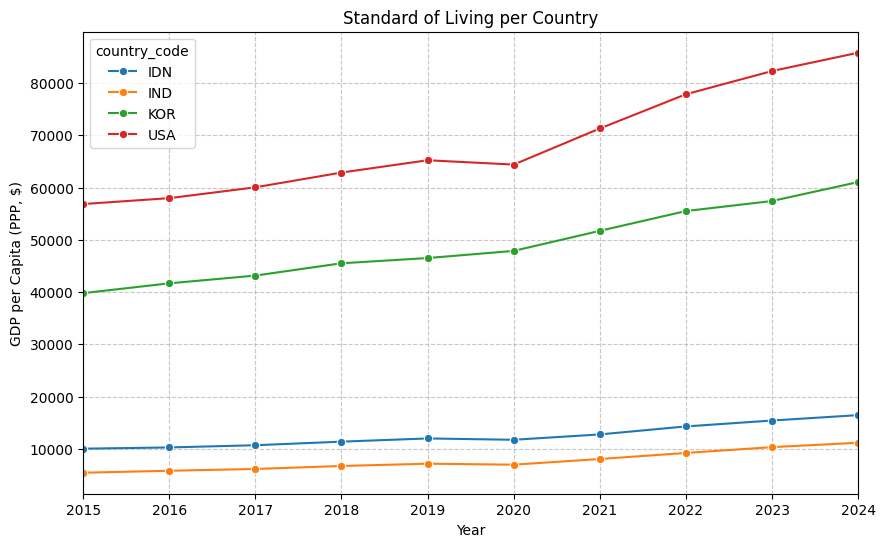

In [18]:
plot_indicator('gdp_per_capita', 'Standard of Living per Country', 'GDP per Capita (PPP, $)')

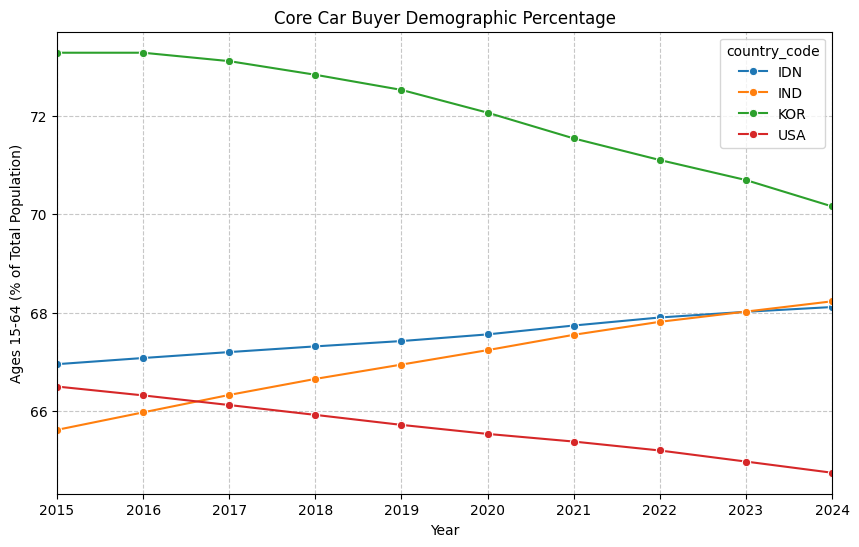

In [19]:
plot_indicator('pop_work_age_pct', 'Core Car Buyer Demographic Percentage', 'Ages 15-64 (% of Total Population)')

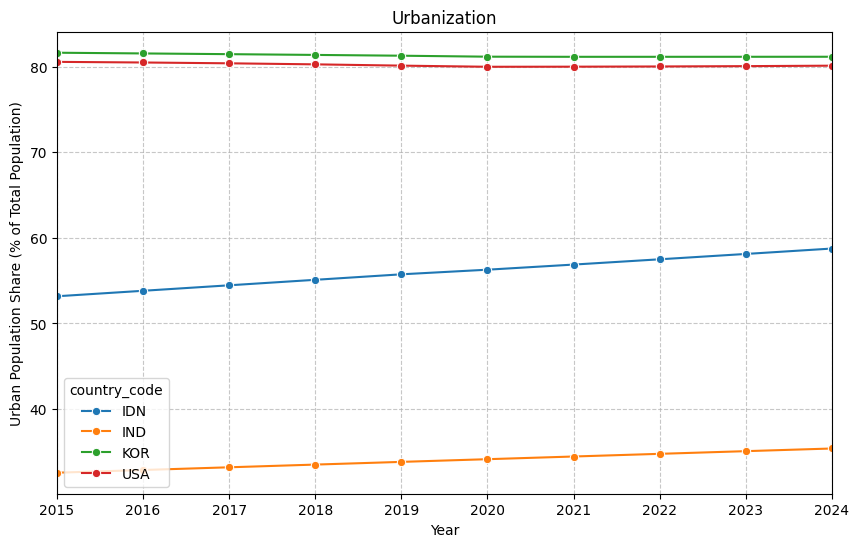

In [20]:
plot_indicator('urban_pop_pct', 'Urbanization', 'Urban Population Share (% of Total Population)')

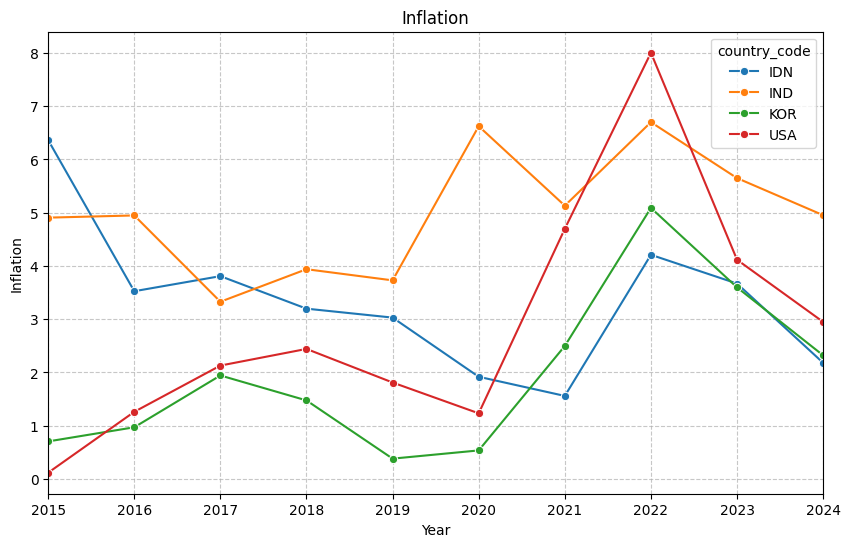

In [21]:
plot_indicator('inflation', 'Inflation', 'Inflation')

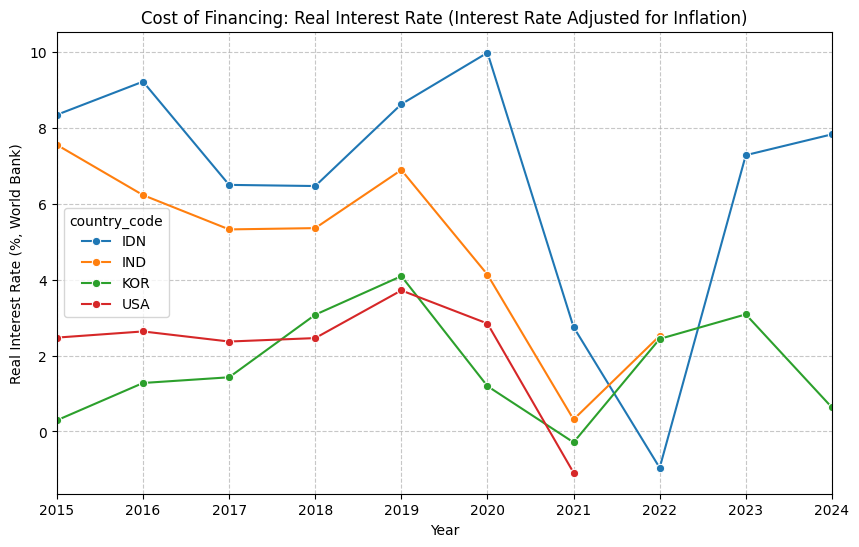

In [22]:
plot_indicator('real_interest_rate', 'Cost of Financing: Real Interest Rate (Interest Rate Adjusted for Inflation)', 'Real Interest Rate (%, World Bank)')

In [23]:
conn.close()